In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [39]:
orders = pd.read_csv(
    "../data/raw/orders.csv"
)

print("Orders dataset loaded successfully.")
print("Shape:", orders.shape)

Orders dataset loaded successfully.
Shape: (5000, 10)


In [40]:
orders.head()

,order_id,customer_id,restaurant_id,order_timestamp,order_amount,number_of_items,weather,traffic_condition,order_status,preparation_time_minutes
0,ORD_00001,CUST_0785,REST_025,2026-05-10 00:04:01,100.00,1,Cloudy,Medium,Delivered,28.0
1,ORD_00002,CUST_0894,REST_066,2026-04-30 05:33:18,396.77,1,Cloudy,Low,Delivered,30.0
2,ORD_00003,CUST_0776,REST_100,2026-02-03 10:44:48,197.80,5,Clear,Low,Delivered,38.0
3,ORD_00004,CUST_0569,REST_018,2026-05-17 07:27:57,145.79,5,Rain,High,Delivered,32.0
4,ORD_00005,CUST_0298,REST_005,2026-05-21 01:33:11,147.25,2,Rain,Low,Delivered,39.0


In [41]:
print(orders.columns.tolist())

['order_id', 'customer_id', 'restaurant_id', 'order_timestamp', 'order_amount', 'number_of_items', 'weather', 'traffic_condition', 'order_status', 'preparation_time_minutes']


In [42]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  5000 non-null   str    
 1   customer_id               5000 non-null   str    
 2   restaurant_id             5000 non-null   str    
 3   order_timestamp           5000 non-null   str    
 4   order_amount              5000 non-null   float64
 5   number_of_items           5000 non-null   int64  
 6   weather                   5000 non-null   str    
 7   traffic_condition         5000 non-null   str    
 8   order_status              5000 non-null   str    
 9   preparation_time_minutes  5000 non-null   float64
dtypes: float64(2), int64(1), str(7)
memory usage: 390.8 KB


In [43]:
orders["order_timestamp"] = pd.to_datetime(
    orders["order_timestamp"],
    errors="coerce"
)

print(orders["order_timestamp"].dtype)

datetime64[us]


In [44]:
print(
    "Invalid timestamps:",
    orders["order_timestamp"].isna().sum()
)

Invalid timestamps: 0


In [45]:
print(
    "Start date:",
    orders["order_timestamp"].min()
)

print(
    "End date:",
    orders["order_timestamp"].max()
)

Start date: 2026-01-01 00:27:38
End date: 2026-06-30 23:36:20


In [46]:
print(
    orders["order_status"].value_counts()
)

order_status
Delivered    4665
Cancelled     335
Name: count, dtype: int64


In [47]:
orders_ts = orders[
    orders["order_status"] == "Delivered"
].copy()

print(
    "Delivered orders:",
    len(orders_ts)
)

Delivered orders: 4665


In [48]:
orders_ts["timestamp"] = pd.to_datetime(
    orders_ts["order_timestamp"]
)

print(
    orders_ts[
        ["order_timestamp", "timestamp"]
    ].head()
)

      order_timestamp           timestamp
0 2026-05-10 00:04:01 2026-05-10 00:04:01
1 2026-04-30 05:33:18 2026-04-30 05:33:18
2 2026-02-03 10:44:48 2026-02-03 10:44:48
3 2026-05-17 07:27:57 2026-05-17 07:27:57
4 2026-05-21 01:33:11 2026-05-21 01:33:11


In [49]:
hourly_demand = (
    orders_ts
    .set_index("timestamp")
    .resample("h")
    .size()
    .to_frame("order_count")
)

print("Hourly demand created successfully.")
print("Shape:", hourly_demand.shape)

Hourly demand created successfully.
Shape: (4344, 1)


In [50]:
print(
    "Index type:",
    type(hourly_demand.index)
)

print(
    "Index dtype:",
    hourly_demand.index.dtype
)

Index type: <class 'pandas.DatetimeIndex'>
Index dtype: datetime64[us]


In [51]:
hourly_demand.head(10)

,order_count
timestamp,
2026-01-01 00:00:00,1
2026-01-01 01:00:00,0
2026-01-01 02:00:00,3
2026-01-01 03:00:00,1
2026-01-01 04:00:00,1
2026-01-01 05:00:00,2
2026-01-01 06:00:00,1
2026-01-01 07:00:00,0
2026-01-01 08:00:00,0


In [54]:
print(
    "Missing values:",
    hourly_demand["order_count"].isna().sum()
)

Missing values: 0


In [55]:
print(
    hourly_demand["order_count"].describe()
)

count    4344.000000
mean        1.073895
std         1.048367
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: order_count, dtype: float64


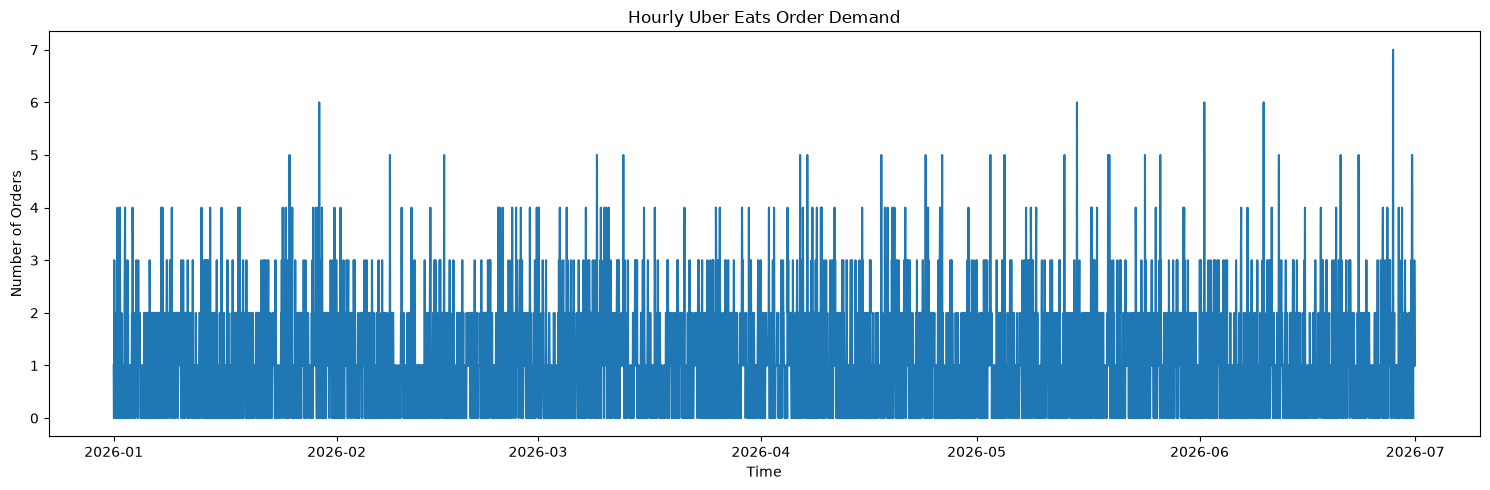

In [56]:
plt.figure(figsize=(15, 5))

plt.plot(
    hourly_demand.index,
    hourly_demand["order_count"]
)

plt.title("Hourly Uber Eats Order Demand")
plt.xlabel("Time")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

In [57]:
hourly_demand.to_csv(
    "../data/processed/hourly_demand.csv"
)

print(
    "Hourly demand dataset saved successfully."
)

Hourly demand dataset saved successfully.


In [58]:
hourly_demand["hour"] = hourly_demand.index.hour

hourly_demand["day_of_week"] = hourly_demand.index.dayofweek

hourly_demand["day_name"] = hourly_demand.index.day_name()

hourly_demand["is_weekend"] = (
    hourly_demand["day_of_week"] >= 5
).astype(int)

hourly_demand.head()

,order_count,hour,day_of_week,day_name,is_weekend
timestamp,,,,,
2026-01-01 00:00:00,1,0,3,Thursday,0
2026-01-01 01:00:00,0,1,3,Thursday,0
2026-01-01 02:00:00,3,2,3,Thursday,0
2026-01-01 03:00:00,1,3,3,Thursday,0
2026-01-01 04:00:00,1,4,3,Thursday,0


In [59]:
hourly_pattern = (
    hourly_demand
    .groupby("hour")["order_count"]
    .mean()
)

print(hourly_pattern)

hour
0     1.204420
1     1.038674
2     1.060773
3     1.071823
4     1.132597
5     1.033149
6     1.005525
7     1.060773
8     1.116022
9     1.082873
10    1.121547
11    1.154696
12    1.099448
13    1.138122
14    1.066298
15    1.022099
16    1.044199
17    1.022099
18    1.016575
19    0.944751
20    1.160221
21    1.000000
22    1.071823
23    1.104972
Name: order_count, dtype: float64


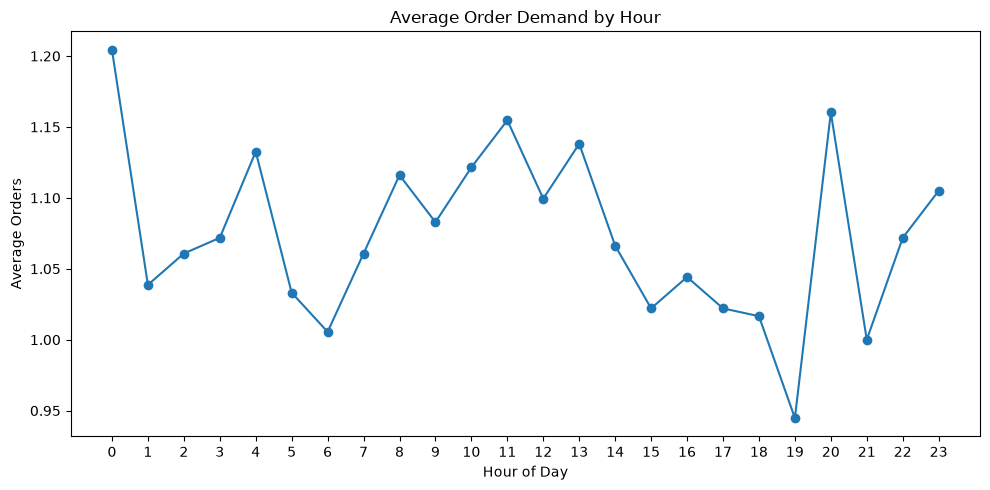

In [60]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker="o"
)

plt.title("Average Order Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Orders")

plt.xticks(range(24))

plt.tight_layout()

plt.show()

In [61]:
daily_pattern = (
    hourly_demand
    .groupby("day_name")["order_count"]
    .mean()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_pattern = daily_pattern.reindex(day_order)

print(daily_pattern)

day_name
Monday       1.048077
Tuesday      1.100962
Wednesday    1.035000
Thursday     1.116987
Friday       1.027244
Saturday     1.125000
Sunday       1.062500
Name: order_count, dtype: float64


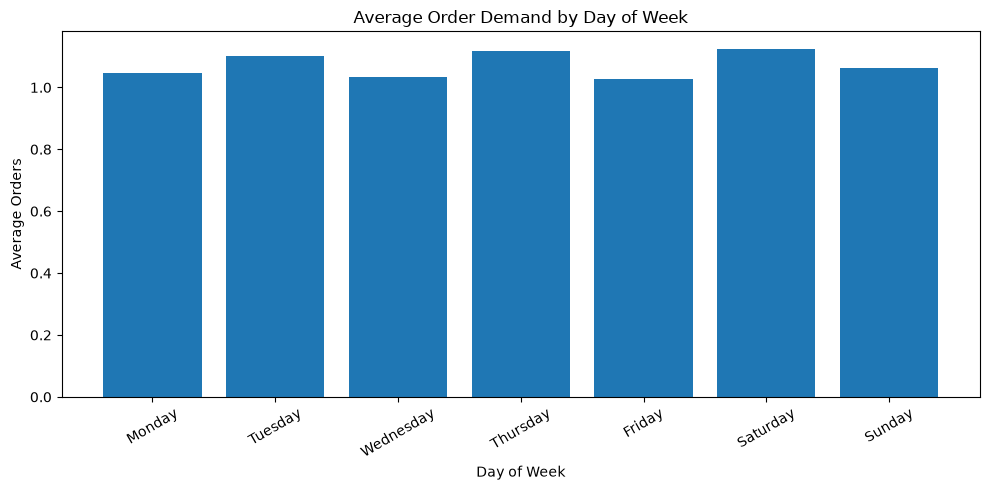

In [62]:
plt.figure(figsize=(10, 5))

plt.bar(
    daily_pattern.index,
    daily_pattern.values
)

plt.title("Average Order Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Orders")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [63]:
weekend_pattern = (
    hourly_demand
    .groupby("is_weekend")["order_count"]
    .mean()
)

weekend_pattern.index = [
    "Weekday" if value == 0 else "Weekend"
    for value in weekend_pattern.index
]

print(weekend_pattern)

Weekday    1.065891
Weekend    1.093750
Name: order_count, dtype: float64


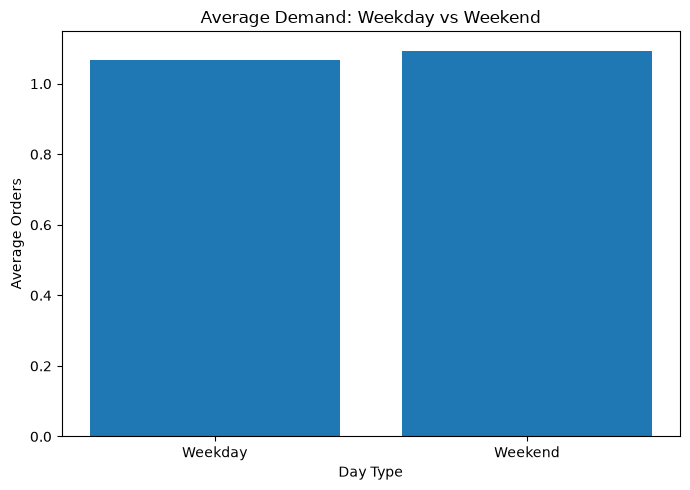

In [65]:
plt.figure(figsize=(7, 5))

plt.bar(
    weekend_pattern.index,
    weekend_pattern.values
)

plt.title("Average Demand: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Orders")

plt.tight_layout()

plt.show()

In [68]:
hourly_weekend_pattern = (
    hourly_demand
    .groupby(["hour", "is_weekend"])["order_count"]
    .mean()
    .unstack()
)

hourly_weekend_pattern.columns = [
    "Weekday",
    "Weekend"
]

print(hourly_weekend_pattern)

       Weekday   Weekend
hour                    
0     1.100775  1.461538
1     1.085271  0.923077
2     1.069767  1.038462
3     1.046512  1.134615
4     1.147287  1.096154
5     1.007752  1.096154
6     1.038760  0.923077
7     1.054264  1.076923
8     1.069767  1.230769
9     1.093023  1.057692
10    1.031008  1.346154
11    1.201550  1.038462
12    1.100775  1.096154
13    1.077519  1.288462
14    1.147287  0.865385
15    0.984496  1.115385
16    1.038760  1.057692
17    0.992248  1.096154
18    1.015504  1.019231
19    0.868217  1.134615
20    1.201550  1.057692
21    1.069767  0.826923
22    1.007752  1.230769
23    1.131783  1.038462


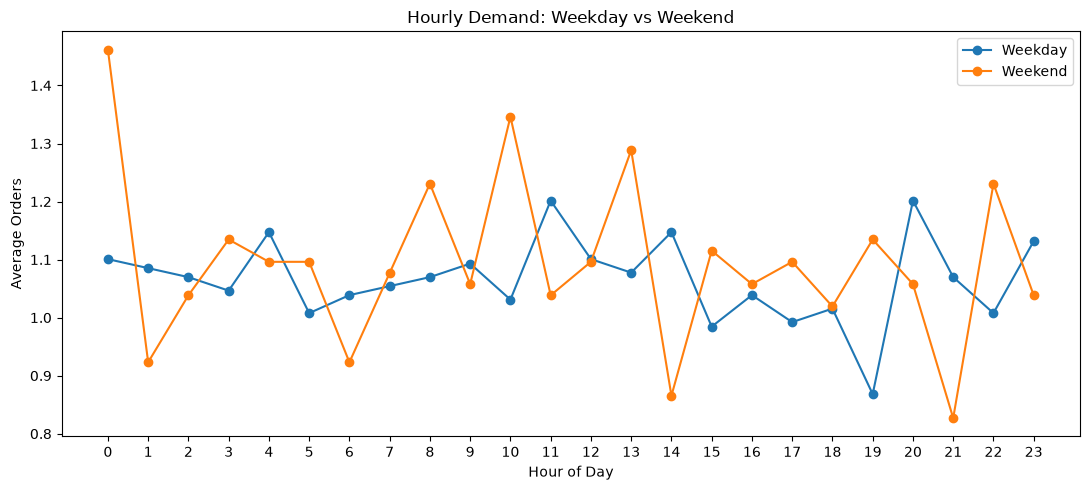

In [69]:
plt.figure(figsize=(11, 5))

plt.plot(
    hourly_weekend_pattern.index,
    hourly_weekend_pattern["Weekday"],
    marker="o",
    label="Weekday"
)

plt.plot(
    hourly_weekend_pattern.index,
    hourly_weekend_pattern["Weekend"],
    marker="o",
    label="Weekend"
)

plt.title("Hourly Demand: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Average Orders")

plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.show()

In [70]:
daily_demand = (
    hourly_demand["order_count"]
    .resample("D")
    .sum()
)

print(daily_demand.head())
print("\nNumber of days:", len(daily_demand))

timestamp
2026-01-01    32
2026-01-02    25
2026-01-03    24
2026-01-04    27
2026-01-05    19
Freq: D, Name: order_count, dtype: int64

Number of days: 181


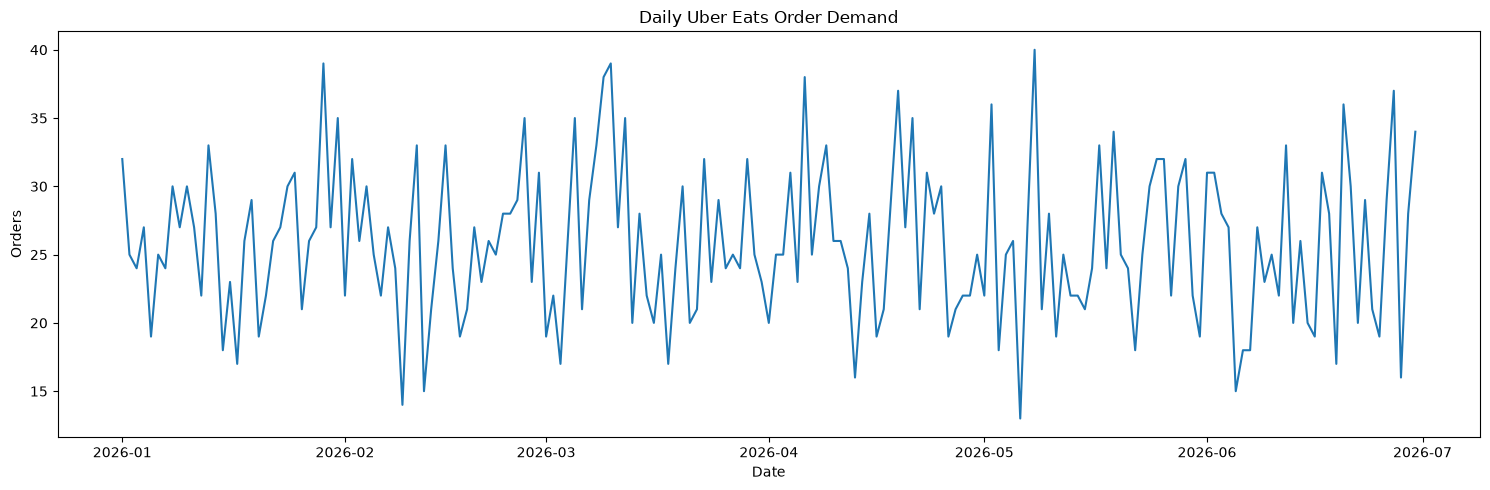

In [71]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily_demand.index,
    daily_demand.values
)

plt.title("Daily Uber Eats Order Demand")
plt.xlabel("Date")
plt.ylabel("Orders")

plt.tight_layout()
plt.show()

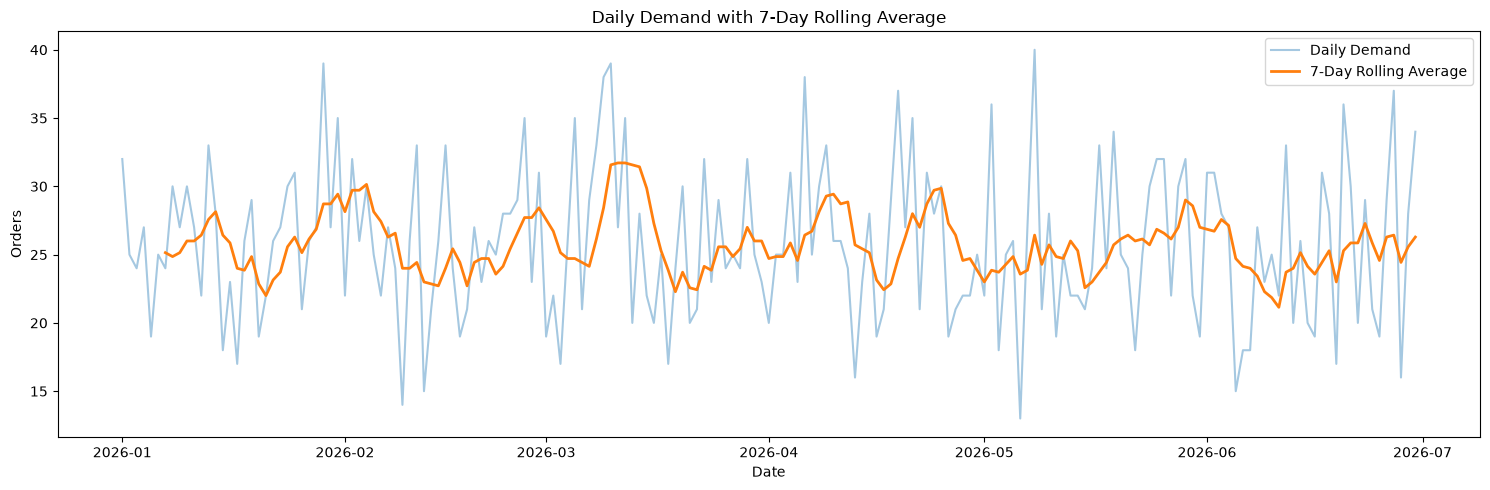

In [72]:
daily_rolling = (
    daily_demand
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(15, 5))

plt.plot(
    daily_demand.index,
    daily_demand.values,
    alpha=0.4,
    label="Daily Demand"
)

plt.plot(
    daily_rolling.index,
    daily_rolling.values,
    linewidth=2,
    label="7-Day Rolling Average"
)

plt.title("Daily Demand with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Orders")

plt.legend()

plt.tight_layout()
plt.show()

In [73]:
peak_hours = (
    hourly_pattern
    .sort_values(ascending=False)
)

print("Top 5 busiest hours:")
print(peak_hours.head(5))

Top 5 busiest hours:
hour
0     1.204420
20    1.160221
11    1.154696
13    1.138122
4     1.132597
Name: order_count, dtype: float64


In [74]:
decomposition = seasonal_decompose(
    hourly_demand["order_count"],
    model="additive",
    period=24
)

print("Time-series decomposition completed successfully.")

Time-series decomposition completed successfully.


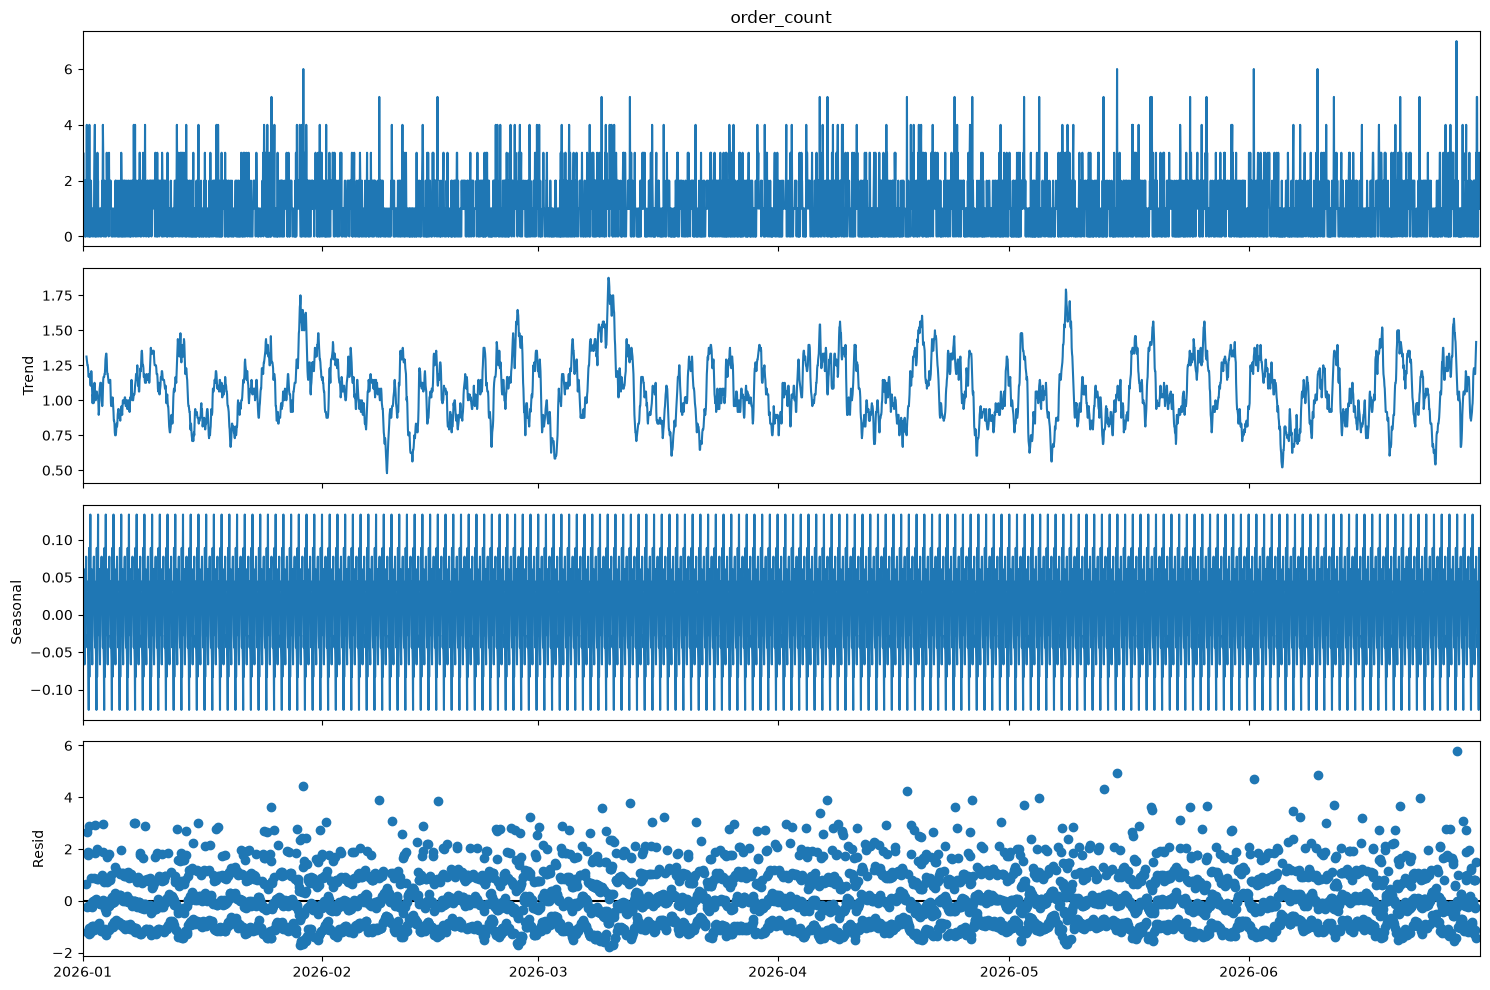

In [75]:
fig = decomposition.plot()

fig.set_size_inches(15, 10)

plt.tight_layout()
plt.show()

In [76]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print("Trend:")
print(trend.dropna().head())

print("\nSeasonal:")
print(seasonal.head(24))

print("\nResidual:")
print(residual.dropna().head())

Trend:
timestamp
2026-01-01 12:00:00    1.312500
2026-01-01 13:00:00    1.291667
2026-01-01 14:00:00    1.270833
2026-01-01 15:00:00    1.250000
2026-01-01 16:00:00    1.250000
Freq: h, Name: trend, dtype: float64

Seasonal:
timestamp
2026-01-01 00:00:00    0.133748
2026-01-01 01:00:00   -0.027247
2026-01-01 02:00:00   -0.022270
2026-01-01 03:00:00   -0.000511
2026-01-01 04:00:00    0.060831
2026-01-01 05:00:00   -0.044377
2026-01-01 06:00:00   -0.066368
2026-01-01 07:00:00   -0.005257
2026-01-01 08:00:00    0.050068
2026-01-01 09:00:00    0.005623
2026-01-01 10:00:00    0.055507
2026-01-01 11:00:00    0.077498
2026-01-01 12:00:00    0.033517
2026-01-01 13:00:00    0.044512
2026-01-01 14:00:00   -0.027479
2026-01-01 15:00:00   -0.043914
2026-01-01 16:00:00   -0.027247
2026-01-01 17:00:00   -0.043798
2026-01-01 18:00:00   -0.060349
2026-01-01 19:00:00   -0.127132
2026-01-01 20:00:00    0.089188
2026-01-01 21:00:00   -0.083034
2026-01-01 22:00:00   -0.005141
2026-01-01 23:00:00    0.0336

In [77]:
print("Trend standard deviation:",
      trend.std())

print("Seasonal standard deviation:",
      seasonal.std())

print("Residual standard deviation:",
      residual.std())

Trend standard deviation: 0.21486550554480804
Seasonal standard deviation: 0.059558915284180565
Residual standard deviation: 1.018342186942284


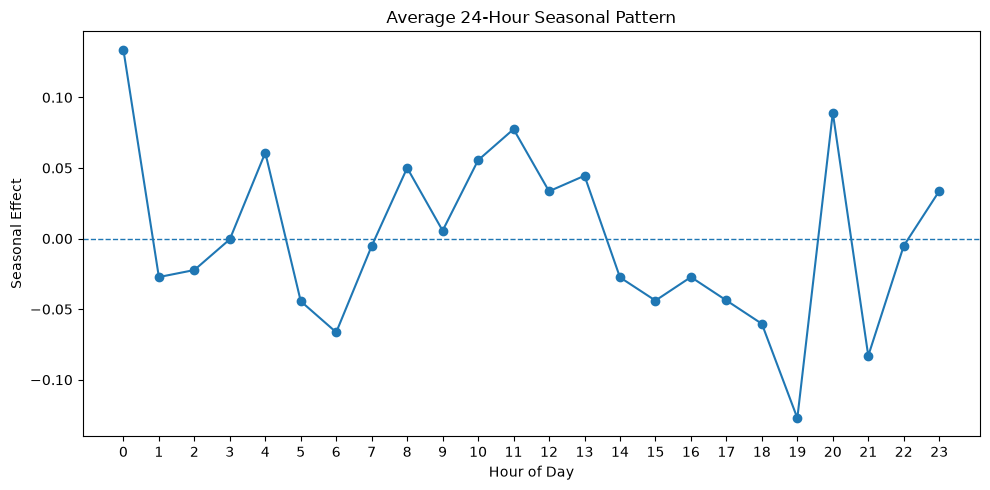

In [78]:
seasonal_hourly = (
    seasonal
    .groupby(seasonal.index.hour)
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    seasonal_hourly.index,
    seasonal_hourly.values,
    marker="o"
)

plt.title("Average 24-Hour Seasonal Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Seasonal Effect")

plt.xticks(range(24))

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.tight_layout()
plt.show()

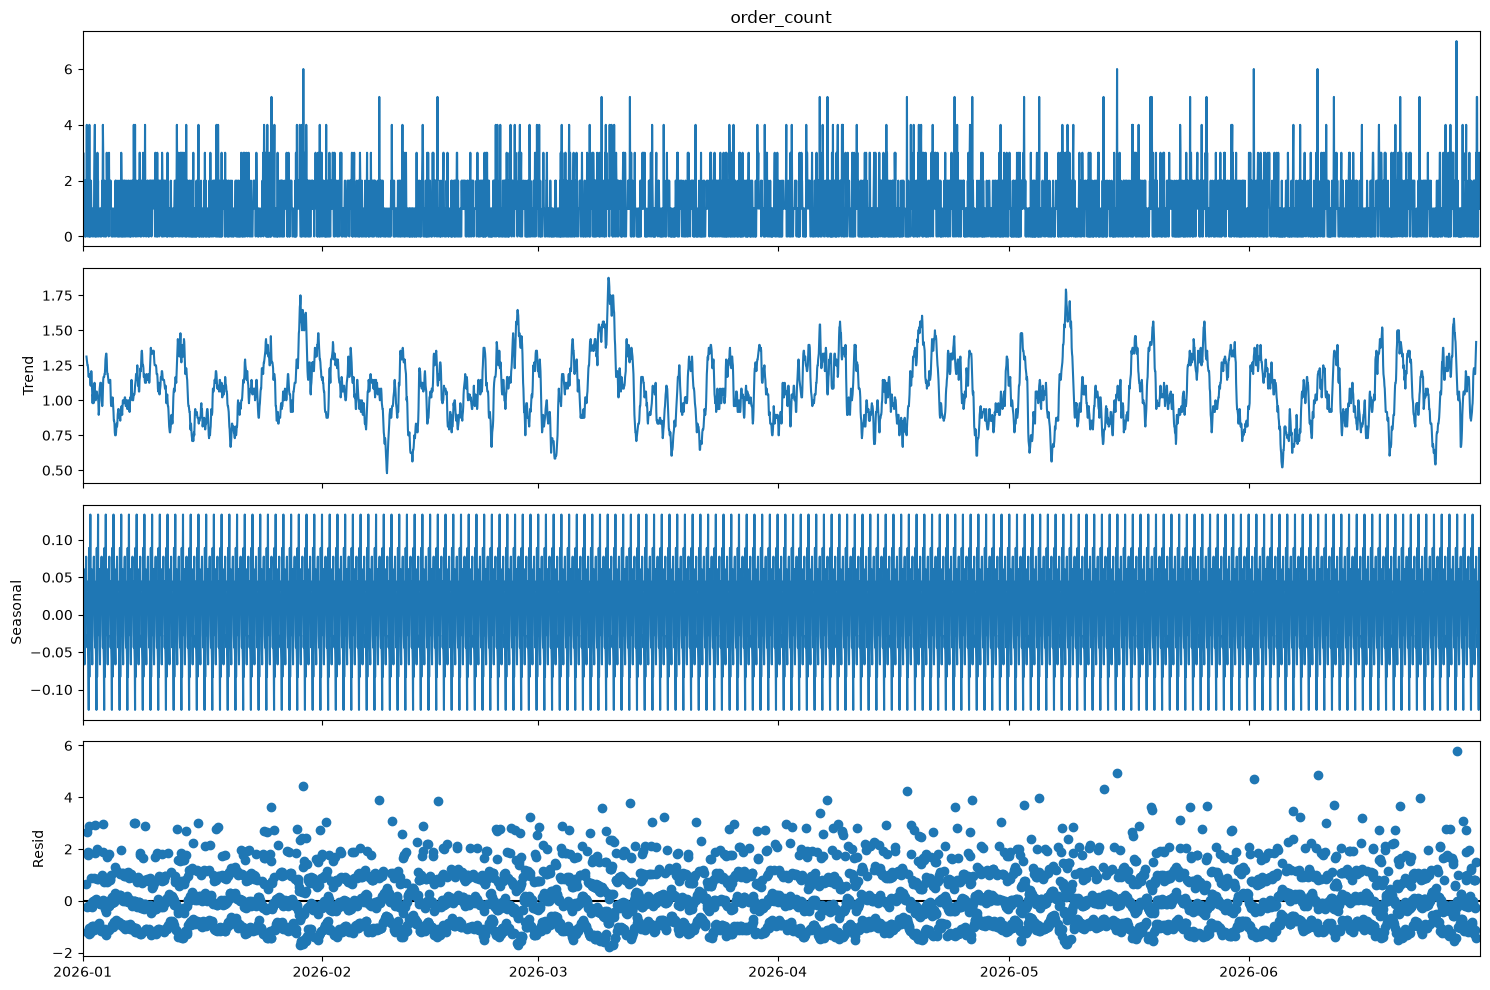

In [79]:
fig = decomposition.plot()

fig.set_size_inches(15, 10)

plt.tight_layout()

fig.savefig(
    "../outputs/plots/hourly_demand_decomposition.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [80]:
adf_result = adfuller(
    hourly_demand["order_count"]
)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags:", adf_result[2])
print("Number of Observations:", adf_result[3])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -65.53832008903944
p-value: 0.0
Number of Lags: 0
Number of Observations: 4343

Critical Values:
1%: -3.431856601262164
5%: -2.8622057326790165
10%: -2.5671243741164944


In [81]:
p_value = adf_result[1]

if p_value <= 0.05:
    print("Result: The series is stationary.")
else:
    print("Result: The series is not stationary.")

Result: The series is stationary.


In [82]:
split_index = int(len(hourly_demand) * 0.8)

train = hourly_demand["order_count"].iloc[:split_index]
test = hourly_demand["order_count"].iloc[split_index:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining start:", train.index.min())
print("Training end:", train.index.max())

print("\nTesting start:", test.index.min())
print("Testing end:", test.index.max())

Training observations: 3475
Testing observations: 869

Training start: 2026-01-01 00:00:00
Training end: 2026-05-25 18:00:00

Testing start: 2026-05-25 19:00:00
Testing end: 2026-06-30 23:00:00


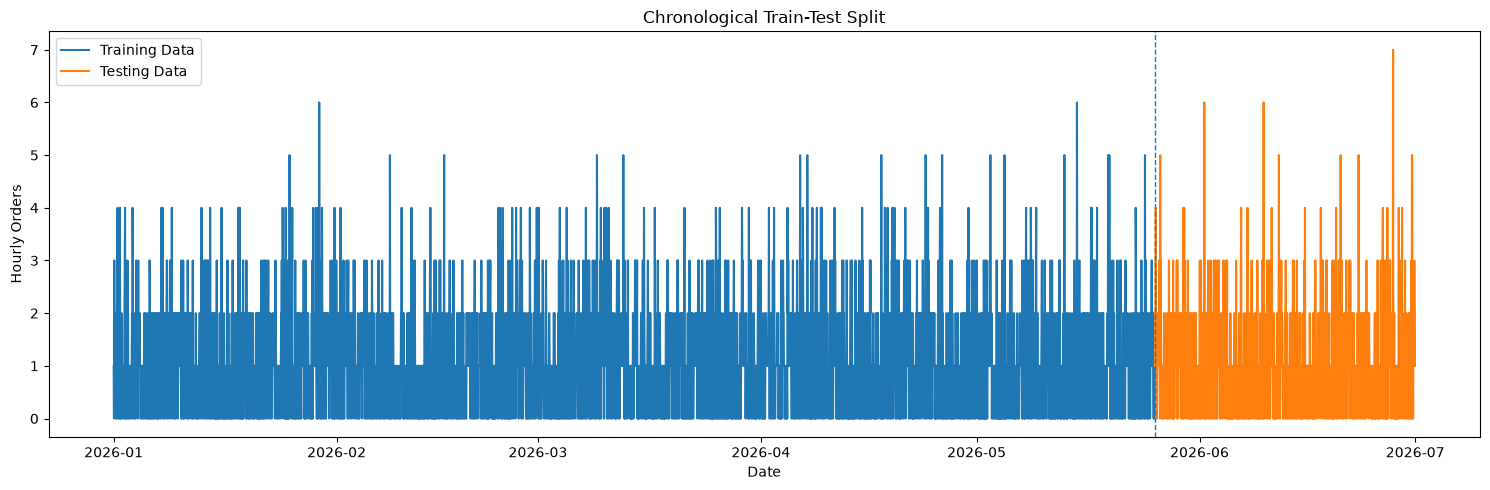

In [83]:
plt.figure(figsize=(15, 5))

plt.plot(
    train.index,
    train.values,
    label="Training Data"
)

plt.plot(
    test.index,
    test.values,
    label="Testing Data"
)

plt.axvline(
    test.index[0],
    linestyle="--",
    linewidth=1
)

plt.title("Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Hourly Orders")

plt.legend()

plt.tight_layout()
plt.show()

In [84]:
print(
    f"Train percentage: {len(train) / len(hourly_demand) * 100:.2f}%"
)

print(
    f"Test percentage: {len(test) / len(hourly_demand) * 100:.2f}%"
)

Train percentage: 80.00%
Test percentage: 20.00%


In [85]:
arima_model = ARIMA(
    train,
    order=(1, 0, 1)
)

arima_fitted = arima_model.fit()

print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:            order_count   No. Observations:                 3475
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -5071.669
Date:                Wed, 19 Aug 2026   AIC                          10151.338
Time:                        11:29:53   BIC                          10175.952
Sample:                    01-01-2026   HQIC                         10160.126
                         - 05-25-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0768      0.021     50.086      0.000       1.035       1.119
ar.L1         -0.1021      5.334     -0.019      0.985     -10.556      10.352
ma.L1          0.0991      5.335      0.019      0.9

In [86]:
arima_forecast = arima_fitted.forecast(
    steps=len(test)
)

arima_forecast.index = test.index

print(arima_forecast.head())
print("\nForecast observations:", len(arima_forecast))

timestamp
2026-05-25 19:00:00    1.079714
2026-05-25 20:00:00    1.076534
2026-05-25 21:00:00    1.076859
2026-05-25 22:00:00    1.076826
2026-05-25 23:00:00    1.076829
Freq: h, Name: predicted_mean, dtype: float64

Forecast observations: 869


In [87]:
arima_mae = mean_absolute_error(
    test,
    arima_forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_forecast
    )
)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 0.7945963150943071
ARIMA RMSE: 1.0753183064728395


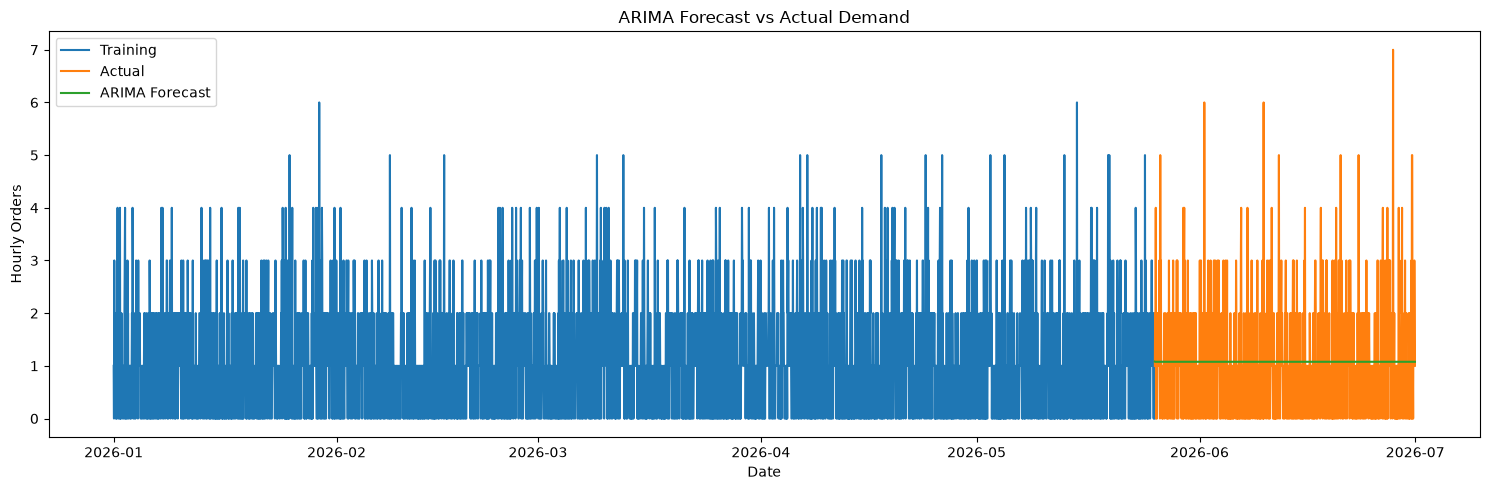

In [88]:
plt.figure(figsize=(15, 5))

plt.plot(
    train.index,
    train.values,
    label="Training"
)

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    arima_forecast.index,
    arima_forecast.values,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Hourly Orders")

plt.legend()

plt.tight_layout()
plt.show()

In [90]:
from prophet import Prophet

print("Prophet imported successfully.")

Importing plotly failed. Interactive plots will not work.


Prophet imported successfully.


In [91]:
prophet_train = train.reset_index()

prophet_train = prophet_train.rename(
    columns={
        "timestamp": "ds",
        "order_count": "y"
    }
)

print(prophet_train.head())
print("\nShape:", prophet_train.shape)

                   ds  y
0 2026-01-01 00:00:00  1
1 2026-01-01 01:00:00  0
2 2026-01-01 02:00:00  3
3 2026-01-01 03:00:00  1
4 2026-01-01 04:00:00  1

Shape: (3475, 2)


In [92]:
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

prophet_model.fit(prophet_train)

print("Prophet model trained successfully.")

11:34:58 - cmdstanpy - INFO - Chain [1] start processing
11:34:58 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.


In [93]:
future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq="h"
)

print(future.tail())
print("\nTotal timestamps:", len(future))

                      ds
4339 2026-06-30 19:00:00
4340 2026-06-30 20:00:00
4341 2026-06-30 21:00:00
4342 2026-06-30 22:00:00
4343 2026-06-30 23:00:00

Total timestamps: 4344


In [94]:
prophet_forecast = prophet_model.predict(future)

print(
    prophet_forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].tail()
)

                      ds      yhat  yhat_lower  yhat_upper
4339 2026-06-30 19:00:00  0.964577   -0.391639    2.301660
4340 2026-06-30 20:00:00  0.990602   -0.294961    2.289900
4341 2026-06-30 21:00:00  1.015593   -0.283094    2.338790
4342 2026-06-30 22:00:00  1.030842   -0.312995    2.420975
4343 2026-06-30 23:00:00  1.032087   -0.343958    2.363827


In [95]:
prophet_test_forecast = prophet_forecast[
    ["ds", "yhat"]
].tail(len(test)).copy()

prophet_test_forecast = prophet_test_forecast.set_index("ds")

print(prophet_test_forecast.head())
print("\nForecast observations:", len(prophet_test_forecast))

                         yhat
ds                           
2026-05-25 19:00:00  0.985606
2026-05-25 20:00:00  1.019592
2026-05-25 21:00:00  1.052215
2026-05-25 22:00:00  1.074637
2026-05-25 23:00:00  1.082477

Forecast observations: 869


In [96]:
prophet_mae = mean_absolute_error(
    test,
    prophet_test_forecast["yhat"]
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test,
        prophet_test_forecast["yhat"]
    )
)

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)

Prophet MAE: 0.7925070554471715
Prophet RMSE: 1.0794950451945442


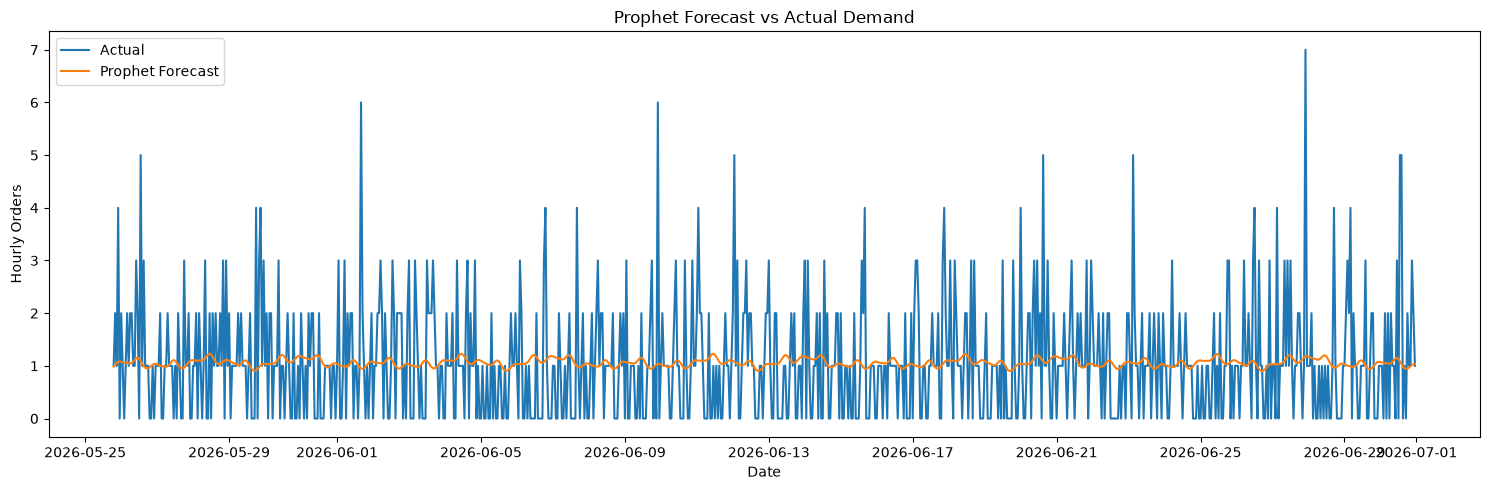

In [97]:
plt.figure(figsize=(15, 5))

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    prophet_test_forecast.index,
    prophet_test_forecast["yhat"],
    label="Prophet Forecast"
)

plt.title("Prophet Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Hourly Orders")

plt.legend()

plt.tight_layout()
plt.show()

In [98]:
model_comparison = pd.DataFrame({
    "Model": ["ARIMA", "Prophet"],
    "MAE": [arima_mae, prophet_mae],
    "RMSE": [arima_rmse, prophet_rmse]
})

print(model_comparison)

     Model       MAE      RMSE
0    ARIMA  0.794596  1.075318
1  Prophet  0.792507  1.079495


In [99]:
best_mae_model = model_comparison.loc[
    model_comparison["MAE"].idxmin(),
    "Model"
]

print("Best model based on MAE:", best_mae_model)

Best model based on MAE: Prophet


In [100]:
best_rmse_model = model_comparison.loc[
    model_comparison["RMSE"].idxmin(),
    "Model"
]

print("Best model based on RMSE:", best_rmse_model)

Best model based on RMSE: ARIMA


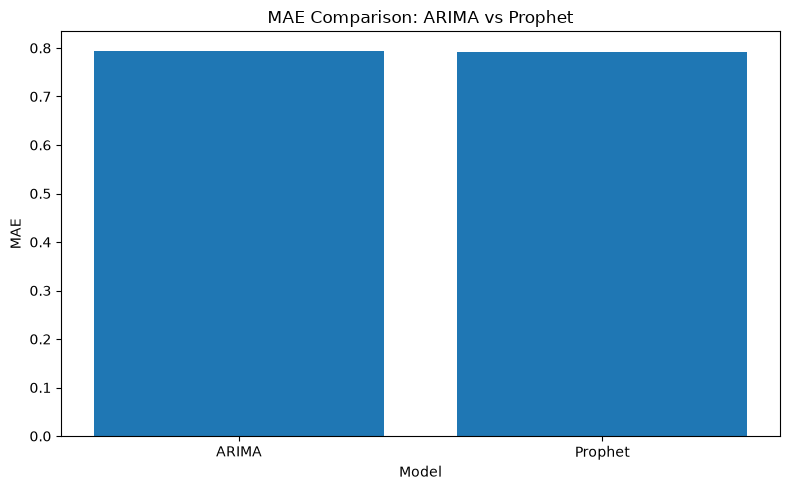

In [101]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

plt.title("MAE Comparison: ARIMA vs Prophet")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.tight_layout()
plt.show()

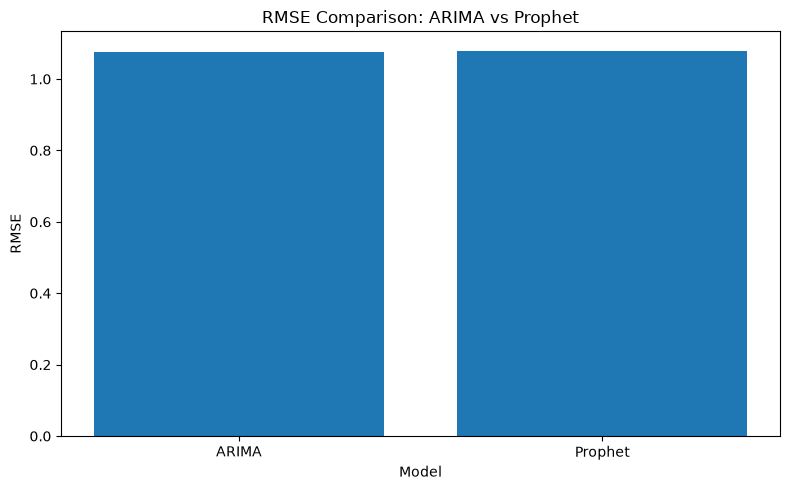

In [102]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

plt.title("RMSE Comparison: ARIMA vs Prophet")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.tight_layout()
plt.show()

In [103]:
model_comparison.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


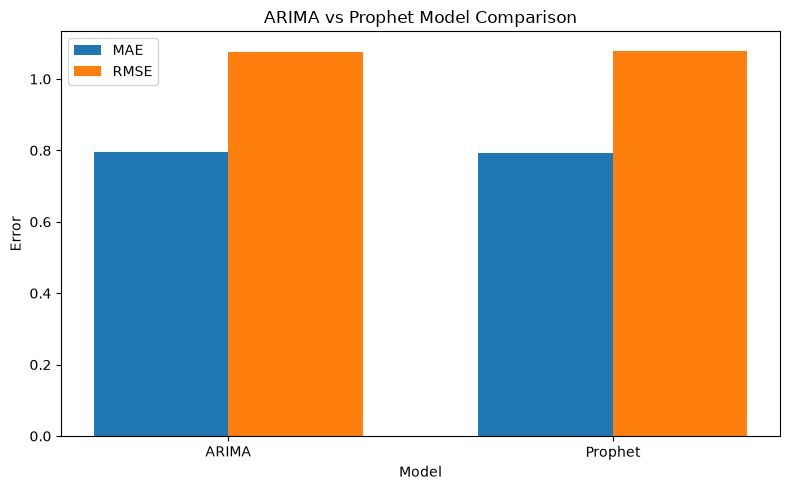

In [104]:
plt.figure(figsize=(8, 5))

x = np.arange(len(model_comparison))
width = 0.35

plt.bar(
    x - width / 2,
    model_comparison["MAE"],
    width,
    label="MAE"
)

plt.bar(
    x + width / 2,
    model_comparison["RMSE"],
    width,
    label="RMSE"
)

plt.xticks(
    x,
    model_comparison["Model"]
)

plt.title("ARIMA vs Prophet Model Comparison")
plt.xlabel("Model")
plt.ylabel("Error")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/plots/arima_vs_prophet_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [105]:
print("ARIMA MAE:", arima_mae)
print("Prophet MAE:", prophet_mae)

print("\nARIMA RMSE:", arima_rmse)
print("Prophet RMSE:", prophet_rmse)

print("\nBest model based on MAE:", best_mae_model)
print("Best model based on RMSE:", best_rmse_model)

ARIMA MAE: 0.7945963150943071
Prophet MAE: 0.7925070554471715

ARIMA RMSE: 1.0753183064728395
Prophet RMSE: 1.0794950451945442

Best model based on MAE: Prophet
Best model based on RMSE: ARIMA


In [106]:
final_model = "ARIMA"

print("Selected final model:", final_model)

Selected final model: ARIMA


In [107]:
final_forecast = arima_fitted.forecast(
    steps=24
)

print(final_forecast)

2026-05-25 19:00:00    1.079714
2026-05-25 20:00:00    1.076534
2026-05-25 21:00:00    1.076859
2026-05-25 22:00:00    1.076826
2026-05-25 23:00:00    1.076829
2026-05-26 00:00:00    1.076829
2026-05-26 01:00:00    1.076829
2026-05-26 02:00:00    1.076829
2026-05-26 03:00:00    1.076829
2026-05-26 04:00:00    1.076829
2026-05-26 05:00:00    1.076829
2026-05-26 06:00:00    1.076829
2026-05-26 07:00:00    1.076829
2026-05-26 08:00:00    1.076829
2026-05-26 09:00:00    1.076829
2026-05-26 10:00:00    1.076829
2026-05-26 11:00:00    1.076829
2026-05-26 12:00:00    1.076829
2026-05-26 13:00:00    1.076829
2026-05-26 14:00:00    1.076829
2026-05-26 15:00:00    1.076829
2026-05-26 16:00:00    1.076829
2026-05-26 17:00:00    1.076829
2026-05-26 18:00:00    1.076829
Freq: h, Name: predicted_mean, dtype: float64


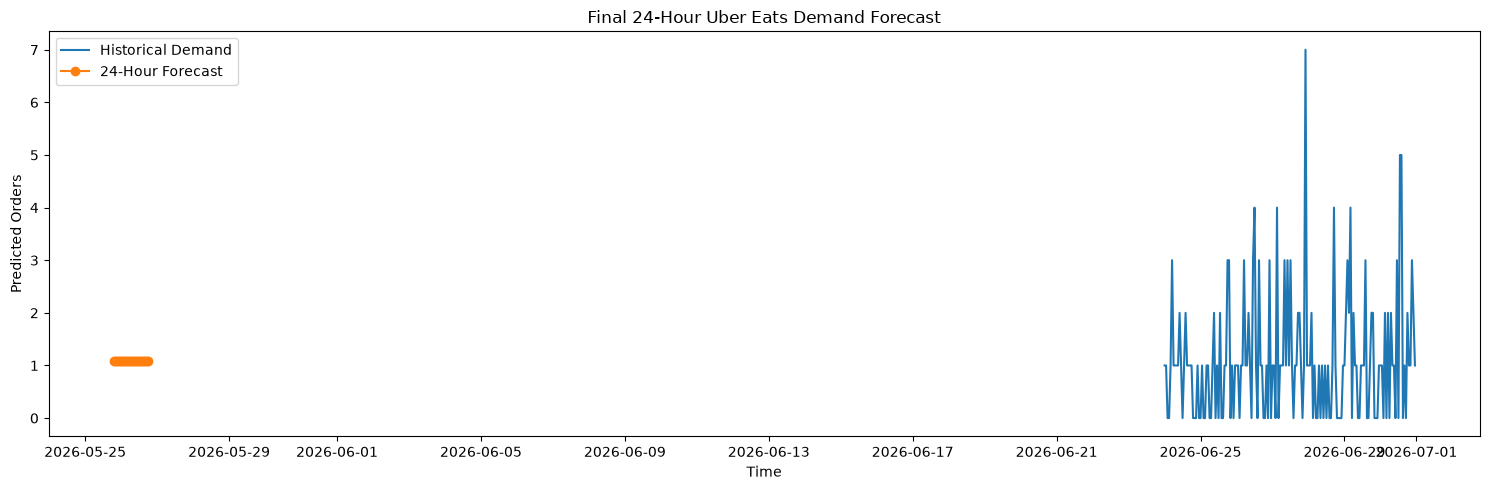

In [108]:
plt.figure(figsize=(15, 5))

plt.plot(
    hourly_demand.index[-168:],
    hourly_demand["order_count"].iloc[-168:],
    label="Historical Demand"
)

plt.plot(
    final_forecast.index,
    final_forecast.values,
    marker="o",
    label="24-Hour Forecast"
)

plt.title("Final 24-Hour Uber Eats Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Predicted Orders")

plt.legend()

plt.tight_layout()
plt.show()

In [109]:
forecast_peak = final_forecast.sort_values(
    ascending=False
)

print("Top 5 forecasted demand hours:")
print(forecast_peak.head(5))

Top 5 forecasted demand hours:
2026-05-25 19:00:00    1.079714
2026-05-25 21:00:00    1.076859
2026-05-25 23:00:00    1.076829
2026-05-26 01:00:00    1.076829
2026-05-26 03:00:00    1.076829
Name: predicted_mean, dtype: float64


In [110]:
final_forecast_df = final_forecast.to_frame(
    name="predicted_order_count"
)

final_forecast_df.to_csv(
    "../data/processed/final_demand_forecast.csv"
)

print("Final forecast saved successfully.")

Final forecast saved successfully.


In [111]:
model_comparison.to_csv(
    "../data/processed/demand_model_comparison.csv",
    index=False
)

print("Model metrics saved successfully.")

Model metrics saved successfully.


In [114]:
print("===== BUSINESS INSIGHTS =====")

print(
    f"Average hourly demand: "
    f"{hourly_demand['order_count'].mean():.2f} orders"
)

print(
    f"Maximum historical hourly demand: "
    f"{hourly_demand['order_count'].max():.0f} orders"
)

print(
    f"Average weekday demand: "
    f"{weekend_pattern['Weekday']:.2f} orders/hour"
)

print(
    f"Average weekend demand: "
    f"{weekend_pattern['Weekend']:.2f} orders/hour"
)

print(
    f"Highest average-demand hour: "
    f"{hourly_pattern.idxmax()}:00"
)

print(
    f"Selected forecasting model: {final_model}"
)

print(
    f"ARIMA RMSE: {arima_rmse:.3f}"
)

print(
    f"Prophet RMSE: {prophet_rmse:.3f}"
)

===== BUSINESS INSIGHTS =====
Average hourly demand: 1.07 orders
Maximum historical hourly demand: 7 orders
Average weekday demand: 1.07 orders/hour
Average weekend demand: 1.09 orders/hour
Highest average-demand hour: 0:00
Selected forecasting model: ARIMA
ARIMA RMSE: 1.075
Prophet RMSE: 1.079


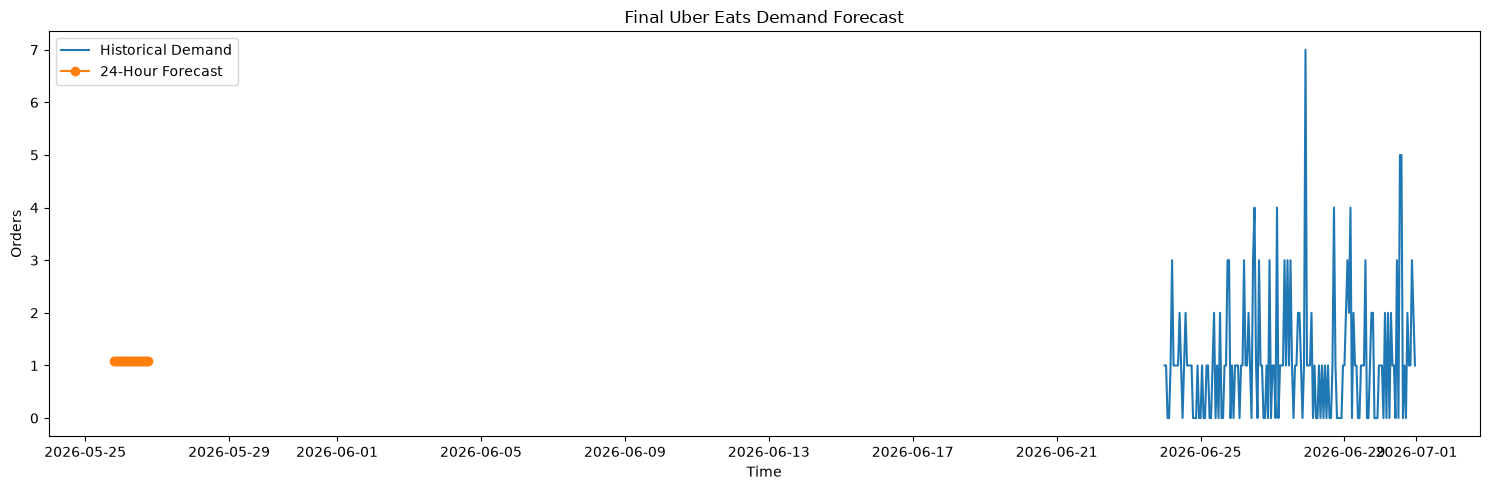

In [113]:
plt.figure(figsize=(15, 5))

plt.plot(
    hourly_demand.index[-168:],
    hourly_demand["order_count"].iloc[-168:],
    label="Historical Demand"
)

plt.plot(
    final_forecast.index,
    final_forecast.values,
    marker="o",
    label="24-Hour Forecast"
)

plt.title("Final Uber Eats Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Orders")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/plots/final_demand_forecast.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()